In [30]:
from pathlib import Path
import numpy as np
from astropy.io import fits
from astropy.stats import sigma_clip
from ccdproc import CCDData, combine, subtract_bias, flat_correct, trim_image
import astroscrappy
import warnings

import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.stats import sigma_clip
import sep
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# Data loading

In [2]:
# fits_skimmer/skimmer.py

# fits_skimmer/skimmer.py

# fits_skimmer/skimmer.py

import glob
from astropy.io import fits
import os

# The single keyword that contains both image type (flat, dark, bias) 
# and band information (u, g, i) in your specific FITS files.
     

def skim_fits_files(directory='.', Keyword='OBJECT' , target_bands=['U', 'G', 'I'], exclusion_list=[]):
    """
    Skims through FITS files, applies an exclusion filter, and categorizes
    calibration frames (flat, dark, bias) by the specified photometry bands,
    using the OBJECT keyword for both type and band identification.

    Parameters:
    - keyword (str): header name for the filter e.g. 'OBJECT' 
    - directory (str): Path to the directory containing the FITS files. Defaults to the current directory.
    - target_bands (list): List of photometry bands to categorize (e.g., ['U', 'G', 'I']).
    - exclusion_list (list): List of strings. Files containing these strings
                             in their name will be skipped.

    Returns:
    - dict: A dictionary containing the categorized file paths.
    """
    # 1. Initialize the data structure
    # Band-specific lists for flats and any other band-specific files
    KEYWORD_COMPOUND = Keyword
    categorized_files = {band.upper(): {'flat': [], 'other': []} for band in target_bands}
    
    # Top-level lists for band-independent frames
    categorized_files['bias_frames'] = []
    categorized_files['dark_frames'] = []
    
    # Lists for unclassified/unwanted files
    categorized_files['unmatched'] = []
    categorized_files['excluded'] = []

    # Ensure bands are uppercase for robust matching
    target_bands = [b.upper() for b in target_bands]

    fits_files = glob.glob(os.path.join(directory, '*.fits'))
    print(f"Found {len(fits_files)} FITS files to check in '{directory}'.")

    for filename in fits_files:
        basename = os.path.basename(filename)
        
        # 2. Exclusion Check
        is_excluded = False
        for exclusion_str in exclusion_list:
            if exclusion_str in basename:
                categorized_files['excluded'].append(filename)
                is_excluded = True
                break
        
        if is_excluded:
            continue # Skip to the next file if excluded

        # 3. Process the FITS File
        try:
            with fits.open(filename, memmap=False) as hdul:
                header = hdul[0].header
                
                # Get the COMPOSITE value (e.g., 'flat_g  ' or 'bias  ')
                composite_value = str(header.get(KEYWORD_COMPOUND, 'UNKNOWN')).lower().strip()

                # --- 4. Categorize by Image Type ---
                
                # A. Band-Independent Frames (Dark/Bias)
                if 'bias' in composite_value or 'zero' in composite_value:
                    categorized_files['bias_frames'].append(filename)
                    continue # Finished with this file, move to the next

                elif 'dark' in composite_value:
                    categorized_files['dark_frames'].append(filename)
                    continue # Finished with this file, move to the next

                # B. Band-Dependent Frames (Flats and other science/standard frames)
                
                image_type = 'other'
                found_band = None
                
                # Check for FLAT frames
                if 'flat' in composite_value:
                    image_type = 'flat'
                
                # Identify the band for flats/other types by checking if a target band 
                # letter (u, g, i) is present in the object string
                for band in target_bands:
                     if band.lower() in composite_value:
                         found_band = band.upper()
                         break
                
                # Store flats and other band-specific frames
                if found_band:
                    categorized_files[found_band][image_type].append(filename)
                
                # If no target band was found or it's a completely unclassified type
                else:
                    categorized_files['unmatched'].append(f"{filename} (OBJECT: {composite_value})")


        except Exception as e:
            print(f"Error processing file {filename}: {e}")

    # 5. Print Summary and Return
    print(f"\n--- Skimming Complete ---")
    print(f"Total FITS files checked: {len(fits_files)}")
    print(f"Total files processed (not excluded): {len(fits_files) - len(categorized_files['excluded'])}")
    print(f"Total files excluded: {len(categorized_files['excluded'])}")
    
    return categorized_files



In [3]:
categorized_files = skim_fits_files(directory='./20250325/', Keyword= 'OBJECT' ,target_bands=['u', 'r', 'z'], exclusion_list=[])




Found 353 FITS files to check in './20250325/'.

--- Skimming Complete ---
Total FITS files checked: 353
Total files processed (not excluded): 353
Total files excluded: 0


In [4]:
categorized_files['Z']['flat']


['./20250325/bs.FLAT.0340.fits',
 './20250325/bs.FLAT.0337.fits',
 './20250325/bs.FLAT.0336.fits',
 './20250325/bs.FLAT.0341.fits',
 './20250325/bs.FLAT.0339.fits',
 './20250325/bs.FLAT.0342.fits',
 './20250325/bs.FLAT.0335.fits',
 './20250325/bs.FLAT.0334.fits',
 './20250325/bs.FLAT.0343.fits',
 './20250325/bs.FLAT.0338.fits',
 './20250325/bs.FLAT.0333.fits']

In [5]:
categorized_files

{'U': {'flat': ['./20250325/bs.FLAT.0106.fits',
   './20250325/bs.FLAT.0110.fits',
   './20250325/bs.FLAT.0111.fits',
   './20250325/bs.FLAT.0107.fits',
   './20250325/bs.FLAT.0114.fits',
   './20250325/bs.FLAT.0115.fits',
   './20250325/bs.FLAT.0108.fits',
   './20250325/bs.FLAT.0112.fits',
   './20250325/bs.FLAT.0113.fits',
   './20250325/bs.FLAT.0109.fits'],
  'other': ['./20250325/bs.OBJECT.0195_amp8_reduced.fits',
   './20250325/bs.OBJECT.0195_amp2_reduced.fits',
   './20250325/bs.OBJECT.0195_amp5_reduced.fits',
   './20250325/bs.OBJECT.0195_amp4_reduced.fits',
   './20250325/bs.OBJECT.0195_amp3_reduced.fits',
   './20250325/bs.OBJECT.0316.fits',
   './20250325/bs.OBJECT.0195_amp1_reduced.fits',
   './20250325/bs.OBJECT.0195_amp6_reduced.fits',
   './20250325/bs.OBJECT.0315.fits',
   './20250325/bs.OBJECT.0195_amp7_reduced.fits',
   './20250325/master_bias.fits']},
 'R': {'flat': ['./20250325/bs.FLAT.0096.fits',
   './20250325/bs.FLAT.0097.fits',
   './20250325/bs.FLAT.0100.fits',

In [6]:
categorized_files['dark_frames']



['./20250325/bs.DARK.0080.fits',
 './20250325/bs.DARK.0079.fits',
 './20250325/bs.DARK.0034.fits',
 './20250325/bs.DARK.0075.fits',
 './20250325/bs.DARK.0074.fits',
 './20250325/bs.DARK.0035.fits',
 './20250325/bs.DARK.0078.fits',
 './20250325/bs.DARK.0081.fits',
 './20250325/bs.DARK.0032.fits',
 './20250325/bs.DARK.0073.fits',
 './20250325/bs.DARK.0086.fits',
 './20250325/bs.DARK.0069.fits',
 './20250325/bs.DARK.0090.fits',
 './20250325/bs.DARK.0091.fits',
 './20250325/bs.DARK.0087.fits',
 './20250325/bs.DARK.0068.fits',
 './20250325/bs.DARK.0072.fits',
 './20250325/bs.DARK.0033.fits',
 './20250325/bs.DARK.0071.fits',
 './20250325/bs.DARK.0067.fits',
 './20250325/bs.DARK.0088.fits',
 './20250325/bs.DARK.0092.fits',
 './20250325/bs.DARK.0084.fits',
 './20250325/bs.DARK.0085.fits',
 './20250325/bs.DARK.0093.fits',
 './20250325/bs.DARK.0066.fits',
 './20250325/bs.DARK.0089.fits',
 './20250325/bs.DARK.0031.fits',
 './20250325/bs.DARK.0070.fits',
 './20250325/bs.DARK.0094.fits',
 './202503

In [7]:
import numpy as np
from typing import List
from astropy.io import fits






def diff_amp(amp_num: int, bias_filesf: List[str], dark_filesf: List[str], flat_filesf: List[str], sciences: List[str]):
    """
    Loads astronomical image data from bias, flat, dark FITS files for a specific amplifier.

    This function reads FITS files for biases, darks, flats, and science images,
    extracts the data from a specified amplifier (HDU) within each file, and
    returns the data in separate lists.

    Args:
        amp_num (int): The HDU index (amplifier number) to extract from each FITS file.
        bias_filesf (List[str]): A list of file paths for bias frames.
        dark_filesf (List[str]): A list of file paths for dark frames.
        flat_filesf (List[str]): A list of file paths for flat-field frames.
        sciences (List[str]): A list of file paths for science images.

    Returns:
        Tuple[List[np.ndarray], ...]: A tuple containing four lists of NumPy arrays:
                                      (biases, darks, flats, sciencesf)
    """
    # Initialize lists to store the image data for each file type
    biases = [0] * len(bias_filesf)
    darks = [0] * len(dark_filesf)
    flats = [0] * len(flat_filesf)
    sciencesf = [0] * len(sciences)
    
    # Loop through each bias and dark file to load the data
    # Note: Both bias and dark loops are combined in your original code.
    for ii in range(len(bias_filesf)):
        # Open the bias FITS file
        file = fits.open(bias_filesf[ii])
        # Extract the data from the specified amplifier (HDU) and store it
        biases[ii] = file[amp_num].data
        
        # Open the dark FITS file and do the same
    for jj in range(len(dark_filesf)):
        # Open the dark FITS file
        file = fits.open(dark_filesf[jj])
        # Extract the data from the specified amplifier (HDU) and store it
        darks[jj] = file[amp_num].data

    # Loop through each flat file to load the data
    for kk in range(len(flat_filesf)):
        # Open the flat FITS file
        file = fits.open(flat_filesf[kk])
        # Extract the data from the specified amplifier (HDU) and store it
        flats[kk] = file[amp_num].data

    # Loop through each science file to load the data
    for k in range(len(sciences)):
        # Open the science FITS file
        file = fits.open(sciences[k])
        # Extract the data from the specified amplifier (HDU) and store it
        sciencesf[k] = file[amp_num].data

    # Return the lists of loaded image data
    return biases, darks, flats, sciencesf



def data_reduction_b(ext,Master_bias, Master_flat, sci,sci_path, plot_normalize_flat:bool=False, plot_final_sci: bool = False,write_output = True):
    """
    Performs basic flat-field and bias correction on astronomical images.

    This function computes master frames (master bias, dark, and flat) by taking the median
    of each input list. It then normalizes the flat frame and uses it to correct the
    science image. It can also optionally plot the master frames and the final science image.

    Args:
        Master_bias ([[np.ndarray]]): Median bias frames.
        Unbiased Dark ([[np.ndarray]]): Unbiased dark frames.
        Master_flat ([[np.ndarray]]): Median flat frames.
        sci (List[np.ndarray]): A list of science images.

        plot_master_flat (bool): If True, plots the normalized master flat frame.
        plot_final_sci (bool): If True, plots the final reduced science image.

    Returns:
        Tuple[np.ndarray, np.ndarray, np.ndarray]: final science image.
    """
    
    # Create a Master Flat frame
    # A master flat is the median of all flat frames, which accounts for pixel sensitivity.
    Master_flat = np.median(flats, axis=0)
    
   
    # Create a Master Science frame
    # The master science frame is the median of all science images.
    Master_science = np.median(sci, axis=0)
    
    # Calculate dark current correction factor
    # This factor scales the dark frame to match the exposure time of the science frame.
    correction_factor = np.mean(Master_science) / np.mean(Master_dark)
    
    # Create a Normalized Flat frame
    # The normalized flat has the dark signal removed and is scaled to unity (1.0).
    Normalized_flat = (Master_flat - Master_dark * correction_factor) / np.median(Master_flat)
    
    if plot_normalize_flat:
        plt.figure()
        plt.title('Normalized Flat')
        plt.imshow(Normalized_flat, vmax=5, origin='lower')

    # 7Perform the final science image reduction
    # This is the core reduction step: (Science - Dark) / Normalized Flat.
    Final_sci = (Master_science - (Master_dark * correction_factor)) / Normalized_flat
    
    if plot_final_sci:
        plt.figure()
        plt.title('Final Reduced Science Image')
        plt.imshow(Final_sci, vmax=np.mean(Final_sci) * 2, origin='lower')

    # Show all generated plots
    plt.show()
    reduced_sci = []
    for hdul in sci_path:
        sci_data = hdul[ext].data.astype(float)
        print (np.median(Final_sci[:,2040:2060]))
        hdr = hdul[ext].header.copy()

        correction_factor = np.median(sci_data)/np.median(Master_dark)
        #Master_science = np.median(sci_data,axis = 0)
#flat =10s, compared to 30 sec of the dark
        final = (sci_data - (Master_dark * correction_factor))/Normalized_flat
        

        #final = (sci_data - (Unbiased_dark * correction_factor)) / Normalized_flat

        reduced_sci.append((final, hdr))
    
    if write_output:
            outname = hdul.filename().replace(".fits", f"_amp{ext}_reduced.fits")
            fits.writeto(outname, final_sci, hdr, overwrite=True)

    hdul.close()

    # Return the processed frames
    return Normalized_flat, Final_sci


def flat_reduction_b(biases, darks, flats, plot_master_bias: bool = False, plot_unbias_dark: bool = False, plot_master_flat: bool = False):
     
    """
    Performs basic flat-field and bias correction on astronomical images.

    This function computes master flat frames by taking the median
    of each input list. It then normalizes the flat frame and uses it to correct the
    science image. It can also optionally plot the master frames and the final science image.

    Args:
        biases (List[np.ndarray]): A list of bias frames.
        darks (List[np.ndarray]): A list of dark frames.
        flats (List[np.ndarray]): A list of flat-field frames.
        sci (List[np.ndarray]): A list of science images.
        plot_master_bias (bool): If True, plots the master bias frame.
        plot_master_flat (bool): If True, plots the normalized master flat frame.
        plot_final_sci (bool): If True, plots the final reduced science image.

    Returns:
        Tuple[np.ndarray, np.ndarray, np.ndarray]: A tuple containing the master flat,
                                                   normalized flat.
    """
    # 1. Create a Master Bias frame
    # A master bias is the median of all bias frames, which removes most of the random noise.
    Master_bias = np.median(biases, axis=0)

    if plot_master_bias:
        plt.figure()
        plt.title('Master Bias')
        plt.imshow(Master_bias, vmax=1200, origin='lower')

    # 2. Create Master Dark and Unbiased Dark frames
    # A master dark is the median of all dark frames, which captures thermal signal.
    Master_dark = np.median(darks, axis=0)
    

    # Remove the bias signal from the master dark frame
    

    # 3. Create a Master Flat frame
    # A master flat is the median of all flat frames, which accounts for pixel sensitivity.
    Master_flat = np.median(flats, axis=0)
    
    if plot_master_flat:
        plt.figure()
        plt.title('Master Flat')
        plt.imshow(Master_flat, vmax=2.5e4, origin='lower')

    return Master_bias, Master_dark,  Master_flat

In [8]:
def reduction(bias_files, dark_files, flat_files, sci_files, ext=1, write_output=False):
    """
    Reduce CCD data for a single amplifier (one FITS extension).

    Parameters
    ----------
    bias_files : list of str
        List of bias FITS filenames
    dark_files : list of str
        List of dark FITS filenames
    flat_files : list of str
        List of flat FITS filenames
    sci_files : list of str
        List of science FITS filenames
    ext : int
        FITS extension index for amplifier (1–8)
    write_output : bool
        If True, write reduced FITS files with suffix "_reduced"

    Returns
    -------
    reduced_sci : list of (ndarray, header)
        List of reduced science images with headers
    """

    # === Load calibration frames for the chosen amplifier ===
    biases = [fits.getdata(f, ext).astype(float) for f in bias_files]
    darks  = [fits.getdata(f, ext).astype(float) for f in dark_files]
    flats  = [fits.getdata(f, ext).astype(float) for f in flat_files]
    sciences = [fits.open(f) for f in sci_files]  # keep headers

    # === Build masters ===
    Master_bias = np.median(biases, axis=0)
    Master_dark = np.median(darks, axis=0)
    Unbiased_dark = Master_dark - Master_bias
    Master_flat = np.median(flats, axis=0)

    # === Apply to science frames ===
    reduced_sci = []
    for hdul in sciences:
        sci_data = hdul[ext].data.astype(float)
        print (np.median(sci_data[:,2040:2060]),np.median(Master_bias[:,2040:2060]))
        hdr = hdul[ext].header.copy()

        correction_factor = np.median(sci_data)/np.median(Master_dark)
        #Master_science = np.median(sci_data,axis = 0)
#flat =10s, compared to 30 sec of the dark
        final = (sci_data - (Master_dark * correction_factor))/Normalized_flat
        

        #final = (sci_data - (Unbiased_dark * correction_factor)) / Normalized_flat

        reduced_sci.append((final, hdr))

        # optionally write to disk
        if write_output:
            outname = hdul.filename().replace(".fits", f"_amp{ext}_reduced.fits")
            fits.writeto(outname, final, hdr, overwrite=True)

        hdul.close()

    return final,reduced_sci,Normalized_flat, Master_flat


In [9]:
categorized_files['Z']['other'][1:2]

['./20250325/bs.OBJECT.0195.fits']

In [10]:
def find_bad_columns(ccd_data: np.ndarray, saturation_threshold: float, black_column_threshold: float,\
sf: float, bf: float) -> List[int]:
    """
    Identifies columns that are either at least half saturated or containing > 25% bad pixels.

    A column is considered "bad" if more than half of its pixels are either:
    1. Greater than or equal to the saturation_threshold (saturated column).
    2. Less than or equal to the black_column_threshold (black or "dead" column).

    Args:
        ccd_data (np.ndarray): A 2D NumPy array representing the CCD image.
        saturation_threshold (float): The value at or above which a pixel
                                      is considered saturated.
        black_column_threshold (float): The value at or below which a pixel
                                        is considered part of a "black" column.
        sf (float): The fraction threshold for saturated pixels in a column (e.g., 0.5 for 50%).
        df (float): The fraction threshold for black pixels in a column (e.g., 0.25 for 25%).

    Returns:
        List[int]: A list of column indices that are identified as bad.
    """
    # Get the number of rows and columns in the image
    rows, cols = ccd_data.shape
    bad_columns = []
    
    print(f"Checking {cols} columns for partially saturated or zero-level pixels...")

    # Iterate through each column
    for j in range(cols):
        # Extract the current column
        column_data = ccd_data[:, j]
        
        # Count the number of pixels meeting the criteria
        saturated_pixel_count = np.sum(column_data >= saturation_threshold)
        black_pixel_count = np.sum(column_data <= black_column_threshold)
        
        # Check if more than half of the pixels are saturated or black
        is_partially_saturated = saturated_pixel_count > rows* sf
        is_partially_black = black_pixel_count > rows * bf

        if is_partially_saturated or is_partially_black:
            bad_columns.append(j)
            if is_partially_saturated:
                print(f"  - Column {j} is partially saturated ({saturated_pixel_count}/{rows} pixels).")
            if is_partially_black:
                print(f"  - Column {j} is partially black ({black_pixel_count}/{rows} pixels).")
        # else:
            # print(f"  - Column {j} is not a bad column.")

    return bad_columns

def create_bad_pixel_map(shape: tuple, bad_columns: List[int]) -> np.ndarray:
    """
    Creates a 2D binary bad pixel map.

    The map will have the same dimensions as the original image and will be
    initialized with zeros. Columns specified as "bad" will be set to 1.

    Args:
        shape (tuple): The (rows, columns) shape of the original image.
        bad_columns (List[int]): A list of column indices to flag as bad.

    Returns:
        np.ndarray: A 2D NumPy array representing the bad pixel map.
    """
    # Create an array of zeros with the specified shape
    bad_map = np.zeros(shape, dtype=int)
    
    # Iterate through the list of bad column indices and set those columns to 1
    for col_index in bad_columns:
        bad_map[:, col_index] = 1

    return bad_map


def mask_bad_columns(ccd_data: np.ndarray, bad_columns: List[int]) -> np.ndarray:
    """
    Masks bad columns by setting their pixel values to NaN.

    This function makes a copy of the data and replaces the values in each
    bad column with np.nan.

    Args:
        ccd_data (np.ndarray): The 2D NumPy array representing the CCD image.
        bad_columns (List[int]): A list of column indices to mask.

    Returns:
        np.ndarray: A new NumPy array with the bad columns masked.
    """
    # Create a copy to avoid modifying the original data
    masked_data = np.copy(ccd_data)
    
    for j in bad_columns:
        masked_data[:, j] = np.nan
            
    return masked_data


def process_and_save_calibrated_image(calibrated_image: np.ndarray, bad_columns: List[int],amp_num: float, output_path: str = './'):
    """
    Processes a calibrated image by masking bad columns and saving the results.

    This function generates a bad pixel map, masks the bad columns in the image,
    visualizes the results, and saves the masked image and the bad pixel map
    as FITS files.

    Args:
        calibrated_image (np.ndarray): The calibrated 2D NumPy array (e.g., Final_sci).
        bad_columns (List[int]): A list of column indices to mask.
        output_path (str): The directory path to save the output files.
    """
    # Create the bad pixel map
    bad_pixel_map = create_bad_pixel_map(calibrated_image.shape, bad_columns)

    # Mask the bad columns in the calibrated image
    masked_image = mask_bad_columns(calibrated_image, bad_columns)

    # --- Visualize the results ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    # Display the original calibrated image (before masking)
    
    axes[0].set_title("Mask Calibrated Image")
    # Display the bad pixel map overlaid on the masked image
    axes[0].imshow(masked_image, cmap='hot')
    axes[1].set_title("Masked Image with Bad Pixel Map")
    axes[1].imshow(bad_pixel_map, cmap='hot', alpha=0.5, vmin=0, vmax=1)
    plt.show()
    
    # --- Save the files to FITS format ---
    # To save the masked image
    masked_hdu = fits.PrimaryHDU(masked_image)
    masked_hdul = fits.HDUList([masked_hdu])
    masked_hdul.writeto(f'{output_path}/masked_image_ampnum_'+str(amp_num)+'.fits', overwrite=True)
    print(f"Saved masked image to: {output_path}/masked_image_ampnum_"+str(amp_num)+'.fits')

    # To save the bad pixel map
    map_hdu = fits.PrimaryHDU(bad_pixel_map)
    map_hdul = fits.HDUList([map_hdu])
    map_hdul.writeto(f'{output_path}/bad_pixel_map_ampnum_'+str(amp_num)+'.fits', overwrite=True)
    print(f"Saved bad pixel map to: {output_path}/bad_pixel_map_ampnum_"+str(amp_num)+'.fits')

    return bad_pixel_map, masked_image

In [12]:
import sep

In [16]:

def diff_amp(amp_num: int, bias_filesf: List[str], dark_filesf: List[str], flat_filesf: List[str], sciences: List[str]):
    """
    Loads astronomical image data from bias, flat, dark FITS files for a specific amplifier.

    This function reads FITS files for biases, darks, flats, and science images,
    extracts the data from a specified amplifier (HDU) within each file, and
    returns the data in separate lists.

    Args:
        amp_num (int): The HDU index (amplifier number) to extract from each FITS file.
        bias_filesf (List[str]): A list of file paths for bias frames.
        dark_filesf (List[str]): A list of file paths for dark frames.
        flat_filesf (List[str]): A list of file paths for flat-field frames.
        sciences (List[str]): A list of file paths for science images.

    Returns:
        Tuple[List[np.ndarray], ...]: A tuple containing four lists of NumPy arrays:
                                      (biases, darks, flats, sciencesf)
    """
    # Initialize lists to store the image data for each file type
    biases = [0] * len(bias_filesf)
    darks = [0] * len(dark_filesf)
    flats = [0] * len(flat_filesf)
    sciencesf = [0] * len(sciences)
    
    # Loop through each bias and dark file to load the data
    # Note: Both bias and dark loops are combined in your original code.
    for ii in range(len(bias_filesf)):
        # Open the bias FITS file
        file = fits.open(bias_filesf[ii])
        # Extract the data from the specified amplifier (HDU) and store it
        biases[ii] = file[amp_num].data
        
        # Open the dark FITS file and do the same
    for jj in range(len(dark_filesf)):
        # Open the dark FITS file
        file = fits.open(dark_filesf[jj])
        # Extract the data from the specified amplifier (HDU) and store it
        darks[jj] = file[amp_num].data

    # Loop through each flat file to load the data
    for kk in range(len(flat_filesf)):
        # Open the flat FITS file
        file = fits.open(flat_filesf[kk])
        # Extract the data from the specified amplifier (HDU) and store it
        flats[kk] = file[amp_num].data

    # Loop through each science file to load the data
    for k in range(len(sciences)):
        # Open the science FITS file
        file = fits.open(sciences[k])
        # Extract the data from the specified amplifier (HDU) and store it
        sciencesf[k] = file[amp_num].data

    # Return the lists of loaded image data
    return biases, darks, flats, sciencesf



def data_reduction_b(ext,Master_bias, Master_flat, sci,sci_path, plot_normalize_flat:bool=False, plot_final_sci: bool = False,write_output = True):
    """
    Performs basic flat-field and bias correction on astronomical images.

    This function computes master frames (master bias, dark, and flat) by taking the median
    of each input list. It then normalizes the flat frame and uses it to correct the
    science image. It can also optionally plot the master frames and the final science image.

    Args:
        Master_bias ([[np.ndarray]]): Median bias frames.
        Unbiased Dark ([[np.ndarray]]): Unbiased dark frames.
        Master_flat ([[np.ndarray]]): Median flat frames.
        sci (List[np.ndarray]): A list of science images.

        plot_master_flat (bool): If True, plots the normalized master flat frame.
        plot_final_sci (bool): If True, plots the final reduced science image.

    Returns:
        Tuple[np.ndarray, np.ndarray, np.ndarray]: final science image.
    """
    
    # Create a Master Flat frame
    # A master flat is the median of all flat frames, which accounts for pixel sensitivity.
    Master_flat = np.median(flats, axis=0)
    
   
    # Create a Master Science frame
    # The master science frame is the median of all science images.
    Master_science = np.median(sci, axis=0)
    
    # Calculate dark current correction factor
    # This factor scales the dark frame to match the exposure time of the science frame.
    correction_factor = np.mean(Master_science) / np.mean(Master_dark)
    
    # Create a Normalized Flat frame
    # The normalized flat has the dark signal removed and is scaled to unity (1.0).
    Normalized_flat = (Master_flat - Master_dark * correction_factor) / np.median(Master_flat)
    
    if plot_normalize_flat:
        plt.figure()
        plt.title('Normalized Flat')
        plt.imshow(Normalized_flat, vmax=5, origin='lower')

    # 7Perform the final science image reduction
    # This is the core reduction step: (Science - Dark) / Normalized Flat.
    Final_sci = (Master_science - (Master_dark * correction_factor)) / Normalized_flat
    
    if plot_final_sci:
        plt.figure()
        plt.title('Final Reduced Science Image')
        plt.imshow(Final_sci, vmax=np.mean(Final_sci) * 2, origin='lower')

    # Show all generated plots
    plt.show()
    reduced_sci = []
   
    sciences = [fits.open(f) for f in sci_path]
    
    reduced_sci = []
    for hdul in sciences:
        sci_data = hdul[ext].data.astype(float)
        print (np.median(sci_data[:,2040:2060]),np.median(Master_bias[:,2040:2060]))
        hdr = hdul[ext].header.copy()

        correction_factor = np.median(sci_data)/np.median(Master_dark)
        #Master_science = np.median(sci_data,axis = 0)
#flat =10s, compared to 30 sec of the dark
        final = (sci_data - (Master_dark * correction_factor))/Normalized_flat
        

        #final = (sci_data - (Unbiased_dark * correction_factor)) / Normalized_flat

        reduced_sci.append((final, hdr))
        print (hdr)
        if write_output:
            outname = hdul.filename().replace(".fits", f"_amp{ext}_reduced.fits")
            fits.writeto(outname, final ,hdr, overwrite=True)

    hdul.close()

    # Return the processed frames
    return Normalized_flat, Final_sci

In [66]:
from scipy.optimize import curve_fit

def radial_profile(data, center):
    y, x = np.indices(data.shape)
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    r = r.astype(int)
    r_max = int(r.max()) + 1
    radial_mean = np.array([data[r == i].mean() for i in range(r_max)])
    return np.arange(r_max), radial_mean

def gaussian(r, a, mu, sigma, c):
    return a * np.exp(-(r-mu)**2/(2*sigma**2)) + c

def sep_run_2(mask_data, threshold, cutout_size=15):
    data = mask_data.astype(np.float32)
    mask = data > (np.median(data) + 5 * np.std(data))
    bkg = sep.Background(data, bw=64, bh=64, fw=3, fh=3, mask=mask)
    data_sub = data - bkg
    objects, segmap = sep.extract(data_sub, thresh=threshold, err=bkg.globalrms, segmentation_map=True, minarea=20)

    print("Number of objects detected:", len(objects))
    print(objects.dtype.names)  # show available columns (x, y, flux, etc.)

    fwhm_sep = 2.355 * np.sqrt(objects['a'] * objects['b'])

    fwhm_radial = []
    flux_in_fwhm = []
    flux_peak_ratio = []
    sep_flags = []
    for i in range(len(objects)):
        x, y = int(objects['x'][i]), int(objects['y'][i])
        sep_flags.append(objects['flag'][i])
        # Check boundaries for cutout
        if (y-cutout_size < 0 or y+cutout_size > data_sub.shape[0] or
            x-cutout_size < 0 or x+cutout_size > data_sub.shape[1]):
            fwhm_radial.append(np.nan)
            flux_in_fwhm.append(np.nan)
            flux_peak_ratio.append(np.nan)
            continue
        cutout = data_sub[y-cutout_size:y+cutout_size, x-cutout_size:x+cutout_size]
        rp_r, rp_flux = radial_profile(cutout, (cutout_size, cutout_size))
        try:
            popt, _ = curve_fit(gaussian, rp_r, rp_flux,
                                p0=[rp_flux.max(), 0, 2, np.median(rp_flux[-5:])])
            sigma = abs(popt[2])
            fwhm = 2.355 * sigma
            fwhm_radial.append(fwhm)
        except Exception:
            fwhm_radial.append(np.nan)
            flux_in_fwhm.append(np.nan)
            flux_peak_ratio.append(np.nan)
            continue
        # Flux inside FWHM radius
        yy, xx = np.indices(cutout.shape)
        rr = np.sqrt((xx - cutout_size)**2 + (yy - cutout_size)**2)
        mask_fwhm = rr <= fwhm_radial[-1] if not np.isnan(fwhm_radial[-1]) else np.zeros_like(rr, dtype=bool)
        flux_fwhm = cutout[mask_fwhm].sum()
        flux_in_fwhm.append(flux_fwhm)
        # Peak pixel
        peak_pix = cutout.max()
        ratio = flux_fwhm / peak_pix if peak_pix != 0 else np.nan
        flux_peak_ratio.append(ratio)

    e = 1 - objects['b'] / objects['a']

    return data_sub, objects, fwhm_sep, fwhm_radial, flux_in_fwhm, flux_peak_ratio, e




In [18]:
categorized_files['Z']['other'][1:2]

['./20250325/bs.OBJECT.0195.fits']

In [19]:
from photutils import detect_sources

<ipython-input-19-d917c8a66439>:1: DeprecationWarning: `photutils.detect_sources` is a deprecated alias for `photutils.segmentation.detect_sources` and will be removed in the future. Instead, please use `from photutils.segmentation import detect_sources` to silence this warning.
  from photutils import detect_sources


1187.0


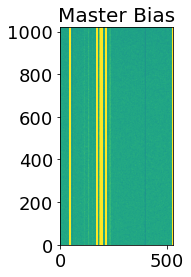

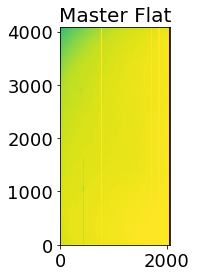

/opt/anaconda3/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


1177.0 nan
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 2060                                                  NAXIS2  =                 4080                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'IM1     '           / extension name                                 BZERO   =              32768.0                                                  BSCALE  =                  1.0                                                  INHERIT =                    T / extension inherits PHDU keyword/values?        BUNIT   = 'ADU     '           / Physical unit of array values                  COMMENT =====================

Checking 2060 columns for partially saturated or zero-level pixels...
  - Column 446 is partially black (1616/4080 pixels).
  - Column 447 is partially black (1616/4080 pixels).
  - Column 771 is partially saturated (4080/4080 pixels).
  - Column 772 is partially saturated (4080/4080 pixels).
  - Column 1709 is partially saturated (4080/4080 pixels).
  - Column 1710 is partially saturated (4080/4080 pixels).
  - Column 1711 is partially saturated (4080/4080 pixels).
  - Column 1712 is partially saturated (4071/4080 pixels).
  - Column 1839 is partially saturated (4080/4080 pixels).
  - Column 1861 is partially saturated (4080/4080 pixels).
  - Column 1862 is partially saturated (4080/4080 pixels).
  - Column 1863 is partially saturated (4080/4080 pixels).
  - Column 2040 is partially black (4080/4080 pixels).
  - Column 2041 is partially black (4080/4080 pixels).
  - Column 2042 is partially black (4080/4080 pixels).
  - Column 2043 is partially black (4080/4080 pixels).
  - Column 204

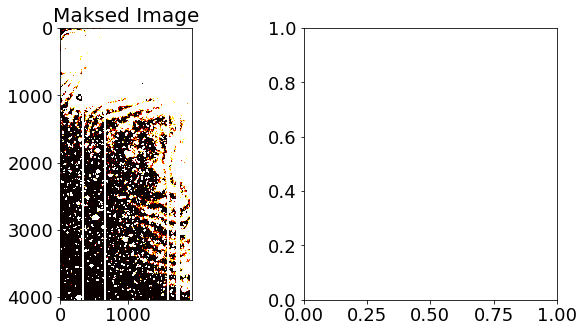

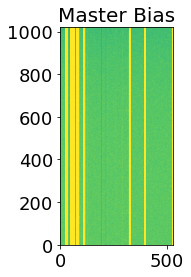

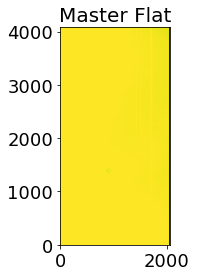

1180.0 nan
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 2060                                                  NAXIS2  =                 4080                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'IM2     '           / extension name                                 BZERO   =              32768.0                                                  BSCALE  =                  1.0                                                  INHERIT =                    T / extension inherits PHDU keyword/values?        BUNIT   = 'ADU     '           / Physical unit of array values                  COMMENT =====================

Number of objects detected: 2108
('thresh', 'npix', 'tnpix', 'xmin', 'xmax', 'ymin', 'ymax', 'x', 'y', 'x2', 'y2', 'xy', 'errx2', 'erry2', 'errxy', 'a', 'b', 'theta', 'cxx', 'cyy', 'cxy', 'cflux', 'flux', 'cpeak', 'peak', 'xcpeak', 'ycpeak', 'xpeak', 'ypeak', 'flag')


/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


1191.0


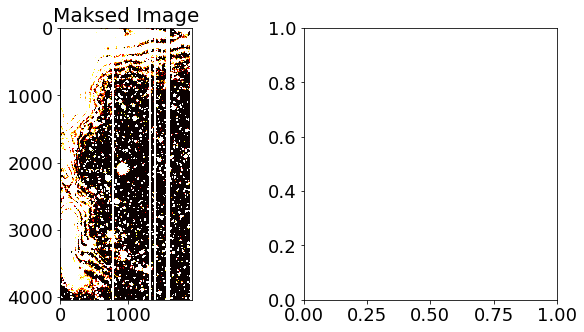

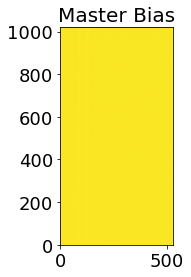

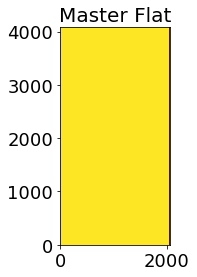

1199.0 nan
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 2060                                                  NAXIS2  =                 4080                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'IM3     '           / extension name                                 BZERO   =              32768.0                                                  BSCALE  =                  1.0                                                  INHERIT =                    T / extension inherits PHDU keyword/values?        BUNIT   = 'ADU     '           / Physical unit of array values                  COMMENT =====================

Checking 2060 columns for partially saturated or zero-level pixels...
  - Column 683 is partially saturated (4080/4080 pixels).
  - Column 684 is partially saturated (4080/4080 pixels).
  - Column 685 is partially saturated (4079/4080 pixels).
  - Column 2040 is partially black (4080/4080 pixels).
  - Column 2041 is partially black (4080/4080 pixels).
  - Column 2042 is partially black (4080/4080 pixels).
  - Column 2043 is partially black (4080/4080 pixels).
  - Column 2044 is partially black (4080/4080 pixels).
  - Column 2045 is partially black (4080/4080 pixels).
  - Column 2046 is partially black (4080/4080 pixels).
  - Column 2047 is partially black (4080/4080 pixels).
  - Column 2048 is partially black (4080/4080 pixels).
  - Column 2049 is partially black (4080/4080 pixels).
  - Column 2050 is partially black (4080/4080 pixels).
  - Column 2051 is partially black (4080/4080 pixels).
  - Column 2052 is partially black (4080/4080 pixels).
  - Column 2053 is partially black (4080/

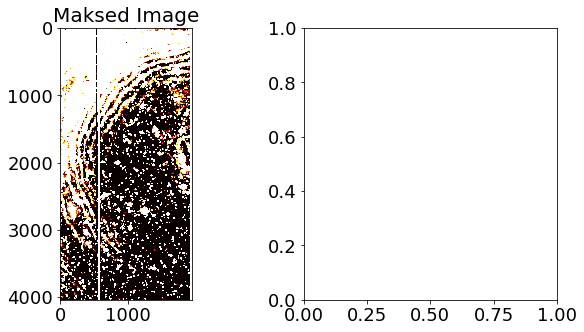

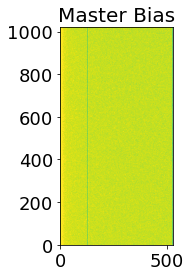

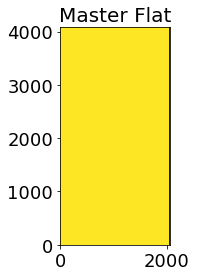

1196.0 nan
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 2060                                                  NAXIS2  =                 4080                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'IM4     '           / extension name                                 BZERO   =              32768.0                                                  BSCALE  =                  1.0                                                  INHERIT =                    T / extension inherits PHDU keyword/values?        BUNIT   = 'ADU     '           / Physical unit of array values                  COMMENT =====================

Checking 2060 columns for partially saturated or zero-level pixels...
  - Column 2040 is partially black (4080/4080 pixels).
  - Column 2041 is partially black (4080/4080 pixels).
  - Column 2042 is partially black (4080/4080 pixels).
  - Column 2043 is partially black (4080/4080 pixels).
  - Column 2044 is partially black (4080/4080 pixels).
  - Column 2045 is partially black (4080/4080 pixels).
  - Column 2046 is partially black (4080/4080 pixels).
  - Column 2047 is partially black (4080/4080 pixels).
  - Column 2048 is partially black (4080/4080 pixels).
  - Column 2049 is partially black (4080/4080 pixels).
  - Column 2050 is partially black (4080/4080 pixels).
  - Column 2051 is partially black (4080/4080 pixels).
  - Column 2052 is partially black (4080/4080 pixels).
  - Column 2053 is partially black (4080/4080 pixels).
  - Column 2054 is partially black (4080/4080 pixels).
  - Column 2055 is partially black (4080/4080 pixels).
  - Column 2056 is partially black (4080/4080 pixe

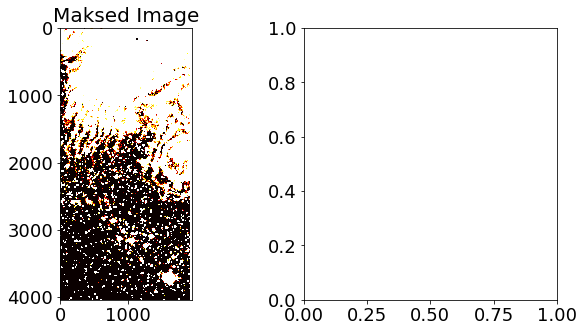

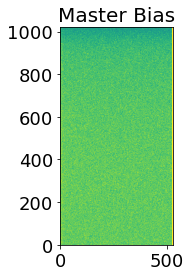

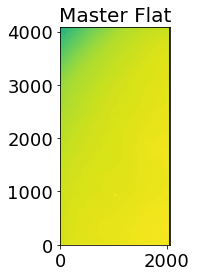

1181.0 nan
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 2060                                                  NAXIS2  =                 4080                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'IM5     '           / extension name                                 BZERO   =              32768.0                                                  BSCALE  =                  1.0                                                  INHERIT =                    T / extension inherits PHDU keyword/values?        BUNIT   = 'ADU     '           / Physical unit of array values                  COMMENT =====================

Checking 2060 columns for partially saturated or zero-level pixels...
  - Column 2040 is partially black (4080/4080 pixels).
  - Column 2041 is partially black (4080/4080 pixels).
  - Column 2042 is partially black (4080/4080 pixels).
  - Column 2043 is partially black (4080/4080 pixels).
  - Column 2044 is partially black (4080/4080 pixels).
  - Column 2045 is partially black (4080/4080 pixels).
  - Column 2046 is partially black (4080/4080 pixels).
  - Column 2047 is partially black (4080/4080 pixels).
  - Column 2048 is partially black (4080/4080 pixels).
  - Column 2049 is partially black (4080/4080 pixels).
  - Column 2050 is partially black (4080/4080 pixels).
  - Column 2051 is partially black (4080/4080 pixels).
  - Column 2052 is partially black (4080/4080 pixels).
  - Column 2053 is partially black (4080/4080 pixels).
  - Column 2054 is partially black (4080/4080 pixels).
  - Column 2055 is partially black (4080/4080 pixels).
  - Column 2056 is partially black (4080/4080 pixe

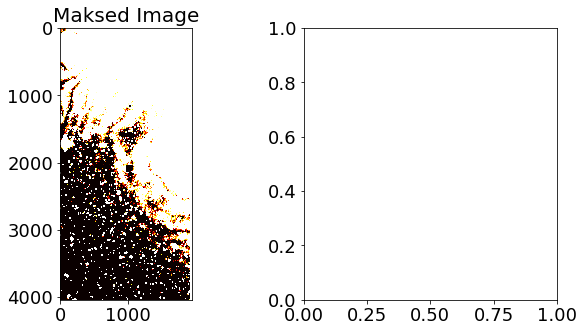

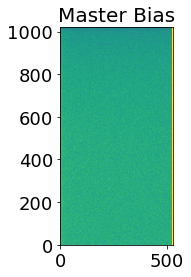

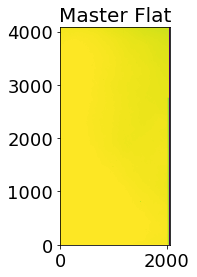

1179.0 nan
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 2060                                                  NAXIS2  =                 4080                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'IM6     '           / extension name                                 BZERO   =              32768.0                                                  BSCALE  =                  1.0                                                  INHERIT =                    T / extension inherits PHDU keyword/values?        BUNIT   = 'ADU     '           / Physical unit of array values                  COMMENT =====================

Checking 2060 columns for partially saturated or zero-level pixels...
  - Column 2019 is partially black (2755/4080 pixels).
  - Column 2020 is partially black (2756/4080 pixels).
  - Column 2023 is partially saturated (2758/4080 pixels).
  - Column 2024 is partially saturated (2758/4080 pixels).
  - Column 2025 is partially saturated (2758/4080 pixels).
  - Column 2026 is partially saturated (2758/4080 pixels).
  - Column 2027 is partially saturated (1833/4080 pixels).
  - Column 2029 is partially black (2422/4080 pixels).
  - Column 2030 is partially black (2755/4080 pixels).
  - Column 2031 is partially black (2750/4080 pixels).
  - Column 2032 is partially black (2749/4080 pixels).
  - Column 2040 is partially black (4080/4080 pixels).
  - Column 2041 is partially black (4080/4080 pixels).
  - Column 2042 is partially black (4080/4080 pixels).
  - Column 2043 is partially black (4080/4080 pixels).
  - Column 2044 is partially black (4080/4080 pixels).
  - Column 2045 is partially b

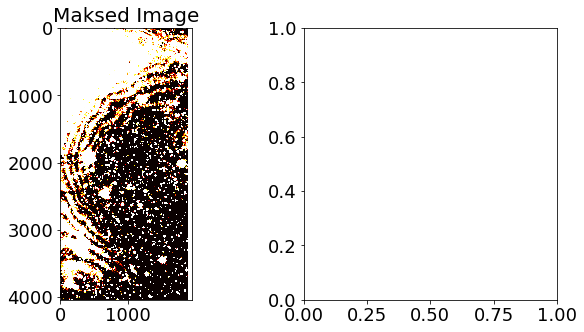

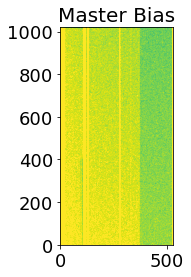

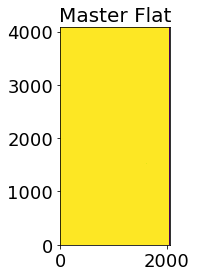

1177.0 nan
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 2060                                                  NAXIS2  =                 4080                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'IM7     '           / extension name                                 BZERO   =              32768.0                                                  BSCALE  =                  1.0                                                  INHERIT =                    T / extension inherits PHDU keyword/values?        BUNIT   = 'ADU     '           / Physical unit of array values                  COMMENT =====================

Checking 2060 columns for partially saturated or zero-level pixels...
  - Column 1779 is partially saturated (4080/4080 pixels).
  - Column 1780 is partially saturated (3599/4080 pixels).
  - Column 2040 is partially black (4080/4080 pixels).
  - Column 2041 is partially black (4080/4080 pixels).
  - Column 2042 is partially black (4080/4080 pixels).
  - Column 2043 is partially black (4080/4080 pixels).
  - Column 2044 is partially black (4080/4080 pixels).
  - Column 2045 is partially black (4080/4080 pixels).
  - Column 2046 is partially black (4080/4080 pixels).
  - Column 2047 is partially black (4080/4080 pixels).
  - Column 2048 is partially black (4080/4080 pixels).
  - Column 2049 is partially black (4080/4080 pixels).
  - Column 2050 is partially black (4080/4080 pixels).
  - Column 2051 is partially black (4080/4080 pixels).
  - Column 2052 is partially black (4080/4080 pixels).
  - Column 2053 is partially black (4080/4080 pixels).
  - Column 2054 is partially black (4080/4

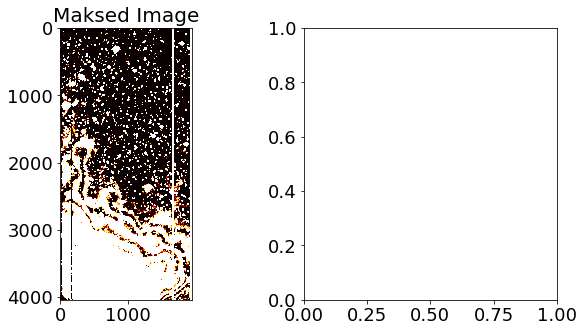

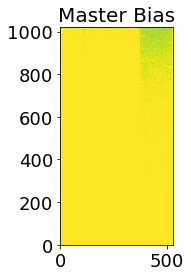

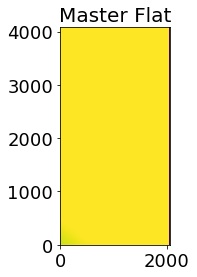

1182.0 nan
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 2060                                                  NAXIS2  =                 4080                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'IM8     '           / extension name                                 BZERO   =              32768.0                                                  BSCALE  =                  1.0                                                  INHERIT =                    T / extension inherits PHDU keyword/values?        BUNIT   = 'ADU     '           / Physical unit of array values                  COMMENT =====================

Checking 2060 columns for partially saturated or zero-level pixels...
  - Column 897 is partially saturated (2870/4080 pixels).
  - Column 1097 is partially saturated (4080/4080 pixels).
  - Column 2040 is partially black (4080/4080 pixels).
  - Column 2041 is partially black (4080/4080 pixels).
  - Column 2042 is partially black (4080/4080 pixels).
  - Column 2043 is partially black (4080/4080 pixels).
  - Column 2044 is partially black (4080/4080 pixels).
  - Column 2045 is partially black (4080/4080 pixels).
  - Column 2046 is partially black (4080/4080 pixels).
  - Column 2047 is partially black (4080/4080 pixels).
  - Column 2048 is partially black (4080/4080 pixels).
  - Column 2049 is partially black (4080/4080 pixels).
  - Column 2050 is partially black (4080/4080 pixels).
  - Column 2051 is partially black (4080/4080 pixels).
  - Column 2052 is partially black (4080/4080 pixels).
  - Column 2053 is partially black (4080/4080 pixels).
  - Column 2054 is partially black (4080/40

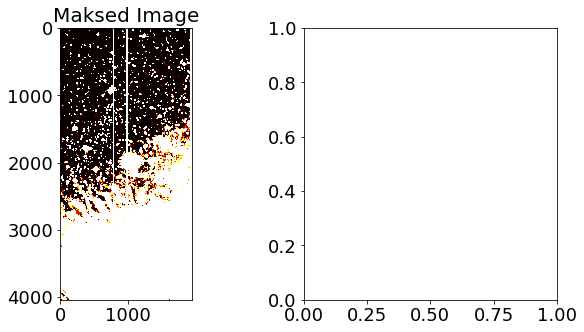

In [67]:
amptot = 9
fwhmt = []
flux_t = []
flux_r=[]
et=[]
threshold = 5
objtot = []
for ii in range(1,amptot):
    biases, darks, flats, sciencesf = diff_amp(ii, categorized_files['bias_frames'][:3],categorized_files['dark_frames'], categorized_files['Z']['flat'], categorized_files['Z']['other'][1:2])
    print (np.median(biases))
    Master_bias, Master_dark,  Master_flat  = flat_reduction_b(biases, darks, flats, plot_master_bias= True, plot_unbias_dark = True, plot_master_flat = True)
    Normalized_flat, Final_sci = Normalized_flat, Final_scii=data_reduction_b(ii,Master_bias,  Master_flat, sciencesf, categorized_files['Z']['other'][1:2],plot_normalize_flat=False, plot_final_sci= False,write_output =True)
#for ii in range(1,num_amp+1):
    bad_columns = find_bad_columns(Master_flat, np.median(Master_flat)+np.std(Master_flat)\
                 ,np.median(Master_flat)-4*np.std(Master_flat), 0.25, 0.2)
    
    scit = fits.open('/Users/Jenny/projects/observation/bok/20250325/bs.OBJECT.0195_amp'+str(ii)+'_reduced.fits')
    
    masked_d = mask_bad_columns(scit[0].data, bad_columns) 
    
    bad_pixel_map = create_bad_pixel_map(Master_flat.shape, bad_columns)
    
    

    # --- Visualize the bad pixel map ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Display the original image
    axes[0].imshow(masked_d[20:4060,105:], cmap='hot',vmin=0, vmax=3)
    axes[0].set_title("Maksed Image")
    data_sub, objects, fwhm_sep, fwhm_radial, flux_in_fwhm, flux_peak_ratio, e = sep_run_2(masked_d,threshold)
    region_filename = f"amp{ii}_sources_ellipse.reg"
    with open(region_filename, "w") as reg:
        reg.write("# Region file format: DS9 version 4.1\n")
        reg.write("image\n")
        for i in range(len(objects)):
            x = objects['x'][i]
            y = objects['y'][i]
            a = objects['a'][i]
            b = objects['b'][i]
            theta = objects['theta'][i] * 180. / np.pi  # DS9 expects degrees
            reg.write(f"ellipse({x},{y},{a},{b},{theta})\n")
   
    et.append(e)
    fwhmt.append(fwhm_radial)
    flux_t.append(flux_in_fwhm)
    flux_r.append(flux_peak_ratio)
    objtot.append(objects)
    
    
    
    #segm = detect_sources(masked_d[20:4060,105:], threshold, npixels=5)
    
    

In [57]:
tables = [Table(obj) for obj in objtot]

# Suppose you want to label subsets 0,1,...,8
labels = []
for i, tab in enumerate(tables):
    labels += [i] * len(tab)

# Stack tables
all_objects = vstack(tables)




# Add subset label column
all_objects['subset_id'] = labels

# Add subset label column
all_objects['FWHM'] = np.concatenate(fwhmt)
all_objects['e'] =np.concatenate(et)
all_objects['flux_ratio'] =np.concatenate(flux_r)

In [49]:
def amp_cut(amp_num,all_objects):
    amp_num = amp_num
    cut = ((all_objects['FWHM']) < 15) &  (all_objects['flag']==0) &  (all_objects['flux_ratio']>2) & (all_objects['subset_id']==amp_num)

    X= np.array([all_objects['FWHM'][cut], all_objects['flux_ratio'][cut], -2.5*np.log(all_objects['flux'][cut]),all_objects['e'][cut]]).T
    
    
    return X
    

In [60]:
cutt = ((all_objects['FWHM']) < 15) &  (all_objects['flag']==0) &  (all_objects['flux_ratio']>2)

In [61]:

Xt = np.array([all_objects['FWHM'][cutt], all_objects['flux_ratio'][cutt], -2.5*np.log(all_objects['flux'][cutt]),all_objects['e'][cutt]]).T
X_scaled = StandardScaler().fit_transform(Xt)

gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(X_scaled)
# 2 clusters: stars vs. not-stars
labelst = gmm.fit_predict(Xt)

In [62]:
median_fwhm = []
for ii in range(0,8):

    median_fwhm.append(np.median(all_objects[cutt][labelst == 0]['FWHM'][all_objects[cutt][labelst == 0]['subset_id']==ii] ))

In [63]:
median_e = []
for ii in range(0,8):

    median_e.append(np.median(all_objects[cutt][labelst == 0]['e'][all_objects[cutt][labelst == 0]['subset_id']==ii] ))
    
    

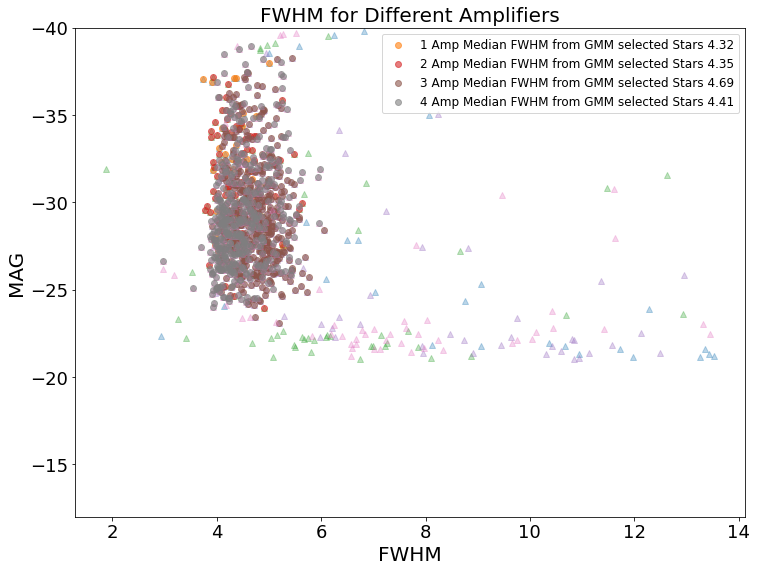

In [64]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 9)) 
plt.rc('axes', titlesize=20)      # Title font size
plt.rc('axes', labelsize=20)      # X/Y label font size
plt.rc('xtick', labelsize=18)     # X tick label font size
plt.rc('ytick', labelsize=18)     # Y tick label font size
plt.rc('legend', fontsize=12)     # Legend font size
plt.rc('figure', titlesize=22)    # Figure title font size
plt.rc('font', size=15)  
for ii in range(0,4):
    X= amp_cut(ii,all_objects)
    cuta = all_objects[cutt][labelst == 0]['subset_id']==ii
    plt.scatter(X[:,0],X[:,2],marker='^',alpha = 0.3)
    plt.scatter(all_objects[cutt][labelst == 0]['FWHM'][cuta],-2.5*np.log(all_objects[cutt][labelst == 0]['flux'][cuta]),marker = 'o',label = str(ii+1)+' Amp Median FWHM from GMM selected Stars '+str(np.round(median_fwhm[ii],2)),alpha=0.6)
#c=labels, cmap='coolwarm'
plt.xlabel("FWHM")
plt.ylabel("MAG")
plt.ylim(-12.,-40)
plt.title("FWHM for Different Amplifiers")
plt.legend()
plt.show()

In [55]:
import tkinter as tk
import numpy as np

# Dummy data for demonstration; replace with your own arrays

cutt = cutt
labelst = 0 # For demonstration

class AmpGridGUI(tk.Tk):
    def __init__(self, all_objects, cutt, labelst):
        super().__init__()
        self.title("Amplifier Grid Median FWHM/E (+Count)")
        self.geometry("1400x750")
        self.all_objects = all_objects
        self.cutt = cutt
        self.labelst = labelst
        self.grid_mode = 1
        self.active_param = 'FWHM'

        # Control panel
        ctrl_frame = tk.Frame(self)
        ctrl_frame.pack(side=tk.TOP, pady=10)
        tk.Button(ctrl_frame, text="Show FWHM", font=("Arial", 14), command=lambda: self.show_param('FWHM')).pack(side=tk.LEFT, padx=10)
        tk.Button(ctrl_frame, text="Show Ellipticity", font=("Arial", 14), command=lambda: self.show_param('e')).pack(side=tk.LEFT, padx=10)
        tk.Label(ctrl_frame, text="Grid:", font=("Arial", 14)).pack(side=tk.LEFT, padx=5)
        self.grid_var = tk.IntVar(value=1)
        grid_menu = tk.OptionMenu(ctrl_frame, self.grid_var, 1, 2, 4, command=self.update_grid_mode)
        grid_menu.config(font=("Arial", 14), width=3)
        grid_menu.pack(side=tk.LEFT)

        self.grid_frame = tk.Frame(self)
        self.grid_frame.pack(side=tk.TOP, fill=tk.BOTH, expand=True)
        self.grid_panels = []

        self.show_param('FWHM')

    def update_grid_mode(self, value):
        self.grid_mode = int(value)
        self.show_param(self.active_param)

    def show_param(self, param):
        self.active_param = param
        for widget in self.grid_frame.winfo_children():
            widget.destroy()
        self.grid_panels.clear()

        grid_per_amp = self.grid_mode
        # Layout: for grid=1, 8 columns; grid=2, 8x2; grid=4, 8x4 panels
        if grid_per_amp == 1:
            total_cols = 8
            total_rows = 1
        elif grid_per_amp == 2:
            total_cols = 8
            total_rows = 2
        elif grid_per_amp == 4:
            total_cols = 8
            total_rows = 4
        else:
            total_cols = 8
            total_rows = 1

        # For each amplifier
        for amp in range(8):
            mask_amp = (self.all_objects['subset_id'][self.cutt] == amp)
            x = self.all_objects['x'][self.cutt][mask_amp]
            y = self.all_objects['y'][self.cutt][mask_amp]
            vals = self.all_objects[param][self.cutt][mask_amp]

            if grid_per_amp == 1:
                median = np.median(vals) if len(vals) else np.nan
                N = len(vals)
                frame = tk.Frame(self.grid_frame, width=120, height=120, bd=2, relief=tk.RIDGE, bg="#eeeeee")
                frame.grid(row=0, column=amp, padx=5, pady=5, sticky="nsew")
                tk.Label(frame, text=f"Amp {amp+1}", font=("Arial", 14, "bold"), bg="#eeeeee").pack(pady=5)
                tk.Label(frame, text=f"Median {param}:\n{median:.3f}", font=("Arial", 12), bg="#eeeeee").pack(pady=8)
                tk.Label(frame, text=f"N = {N}", font=("Arial", 12), bg="#eeeeee", fg="gray").pack(pady=3)
                self.grid_panels.append(frame)
            elif grid_per_amp == 2:
                # Split y into top/bottom
                if len(y):
                    ymid = 0.5 * (y.min() + y.max())
                    in_top = y < ymid
                    in_bottom = y >= ymid
                else:
                    in_top = in_bottom = np.zeros(0, dtype=bool)
                for split, mask in enumerate([in_top, in_bottom]):
                    med = np.median(vals[mask]) if np.sum(mask) else np.nan
                    N = np.sum(mask)
                    frame = tk.Frame(self.grid_frame, width=100, height=100, bd=2, relief=tk.RIDGE, bg="#f7f7f7")
                    frame.grid(row=split, column=amp, padx=2, pady=2, sticky="nsew")
                    tk.Label(frame, text=f"Amp {amp+1}-{'top' if split==0 else 'bottom'}", font=("Arial", 11, "bold"), bg="#f7f7f7").pack(pady=3)
                    tk.Label(frame, text=f"{med:.3f}", font=("Arial", 11), bg="#f7f7f7").pack(pady=4)
                    tk.Label(frame, text=f"N = {N}", font=("Arial", 11), bg="#f7f7f7", fg="gray").pack(pady=2)
                    self.grid_panels.append(frame)
            elif grid_per_amp == 4:
                # Split into 2x2 grid (by x and y)
                if len(x) and len(y):
                    xbins = np.linspace(x.min(), x.max(), 3)
                    ybins = np.linspace(y.min(), y.max(), 3)
                else:
                    xbins = np.linspace(0, 1024, 3)
                    ybins = np.linspace(0, 1024, 3)
                panel_num = 0
                for row in range(2):
                    for col in range(2):
                        in_panel = (
                            (x >= xbins[col]) & (x < xbins[col+1]) &
                            (y >= ybins[row]) & (y < ybins[row+1])
                        )
                        med = np.median(vals[in_panel]) if np.sum(in_panel) else np.nan
                        N = np.sum(in_panel)
                        frame = tk.Frame(self.grid_frame, width=90, height=90, bd=2, relief=tk.RIDGE, bg="#f7f7f7")
                        frame.grid(row=row*2+col, column=amp, padx=2, pady=2, sticky="nsew")
                        tk.Label(frame, text=f"Amp {amp+1}-{panel_num+1}", font=("Arial", 10, "bold"), bg="#f7f7f7").pack(pady=2)
                        tk.Label(frame, text=f"{med:.3f}", font=("Arial", 10), bg="#f7f7f7").pack(pady=2)
                        tk.Label(frame, text=f"N = {N}", font=("Arial", 10), bg="#f7f7f7", fg="gray").pack(pady=2)
                        self.grid_panels.append(frame)
                        panel_num += 1

        for i in range(total_cols):
            self.grid_frame.grid_columnconfigure(i, weight=1)
        for i in range(total_rows):
            self.grid_frame.grid_rowconfigure(i, weight=1)

if __name__ == "__main__":
    app = AmpGridGUI(all_objects, cutt, labelst)
    app.mainloop()

In [68]:
import tkinter as tk
import numpy as np

# Dummy data for demonstration; replace with your own arrays

cutt = cutt
labelst =0  # For demonstration

class AmpGridGUI(tk.Tk):
    def __init__(self, all_objects, cutt, labelst):
        super().__init__()
        self.title("Amplifier Grid with Subgrids (Top 1-4, Bottom 5-8)")
        self.geometry("1500x900")
        self.all_objects = all_objects
        self.cutt = cutt
        self.labelst = labelst
        self.grid_mode = 1
        self.active_param = 'FWHM'

        # Control panel
        ctrl_frame = tk.Frame(self)
        ctrl_frame.pack(side=tk.TOP, pady=10)
        tk.Button(ctrl_frame, text="Show FWHM", font=("Arial", 14), command=lambda: self.show_param('FWHM')).pack(side=tk.LEFT, padx=10)
        tk.Button(ctrl_frame, text="Show Ellipticity", font=("Arial", 14), command=lambda: self.show_param('e')).pack(side=tk.LEFT, padx=10)
        tk.Label(ctrl_frame, text="Subgrids:", font=("Arial", 14)).pack(side=tk.LEFT, padx=5)
        self.grid_var = tk.IntVar(value=1)
        grid_menu = tk.OptionMenu(ctrl_frame, self.grid_var, 1, 2, 4, command=self.update_grid_mode)
        grid_menu.config(font=("Arial", 14), width=3)
        grid_menu.pack(side=tk.LEFT)

        self.amp_frame = tk.Frame(self)
        self.amp_frame.pack(side=tk.TOP, fill=tk.BOTH, expand=True)
        self.amp_panels = []
        self.show_param('FWHM')

    def update_grid_mode(self, value):
        self.grid_mode = int(value)
        self.show_param(self.active_param)

    def show_param(self, param):
        self.active_param = param
        for widget in self.amp_frame.winfo_children():
            widget.destroy()
        self.amp_panels.clear()
        grid_per_amp = self.grid_mode

        # Arrange amplifiers: 1-4 top row, 5-8 bottom row
        for amp in range(8):
            amp_outer_frame = tk.Frame(self.amp_frame, width=200, height=400, bd=4, relief=tk.RIDGE, bg="#cccccc")
            row = 0 if amp < 4 else 1
            col = amp if amp < 4 else amp - 4
            amp_outer_frame.grid(row=row, column=col, padx=5, pady=5, sticky="nsew")
            amp_outer_frame.grid_propagate(False)
            tk.Label(amp_outer_frame, text=f"Amp {amp+1}", font=("Arial", 16, "bold"), bg="#cccccc").pack(side=tk.TOP, pady=3)

            # Subgrid frame inside amplifier
            subgrid_frame = tk.Frame(amp_outer_frame, bg="#dddddd")
            subgrid_frame.pack(fill=tk.BOTH, expand=True, padx=5, pady=5)

            # Get amplifier-specific objects
            mask_amp = (self.all_objects['subset_id'][self.cutt] == amp)
            x = self.all_objects['x'][self.cutt][mask_amp]
            y = self.all_objects['y'][self.cutt][mask_amp]
            vals = self.all_objects[param][self.cutt][mask_amp]

            if grid_per_amp == 1:
                median = np.median(vals) if len(vals) else np.nan
                N = len(vals)
                panel = tk.Frame(subgrid_frame, width=160, height=320, bd=2, relief=tk.GROOVE, bg="#eeeeee")
                panel.pack(fill=tk.BOTH, expand=True, padx=3, pady=3)
                tk.Label(panel, text=f"Median {param}:\n{median:.3f}", font=("Arial", 14), bg="#eeeeee").pack(pady=30)
                tk.Label(panel, text=f"N = {N}", font=("Arial", 13), bg="#eeeeee", fg="gray").pack(pady=5)
            elif grid_per_amp == 2:
                # Split y into top/bottom, 2 vertical panels
                if len(y):
                    ymid = 0.5 * (y.min() + y.max())
                    in_top = y < ymid
                    in_bottom = y >= ymid
                else:
                    in_top = in_bottom = np.zeros(0, dtype=bool)
                for split, mask in enumerate([in_top, in_bottom]):
                    med = np.median(vals[mask]) if np.sum(mask) else np.nan
                    N = np.sum(mask)
                    panel = tk.Frame(subgrid_frame, width=160, height=150, bd=2, relief=tk.GROOVE, bg="#f7f7f7")
                    panel.pack(fill=tk.BOTH, expand=True, padx=3, pady=3)
                    tk.Label(panel, text=f"{'Top' if split==0 else 'Bottom'}", font=("Arial", 12, "bold"), bg="#f7f7f7").pack(pady=2)
                    tk.Label(panel, text=f"{med:.3f}", font=("Arial", 13), bg="#f7f7f7").pack(pady=4)
                    tk.Label(panel, text=f"N = {N}", font=("Arial", 12), bg="#f7f7f7", fg="gray").pack(pady=2)
            elif grid_per_amp == 4:
                # Split into 2x2 grid (by x and y)
                if len(x) and len(y):
                    xbins = np.linspace(x.min(), x.max(), 3)
                    ybins = np.linspace(y.min(), y.max(), 3)
                else:
                    xbins = np.linspace(0, 1024, 3)
                    ybins = np.linspace(0, 1024, 3)
                for row2 in range(2):
                    for col2 in range(2):
                        in_panel = (
                            (x >= xbins[col2]) & (x < xbins[col2+1]) &
                            (y >= ybins[row2]) & (y < ybins[row2+1])
                        )
                        med = np.median(vals[in_panel]) if np.sum(in_panel) else np.nan
                        N = np.sum(in_panel)
                        panel = tk.Frame(subgrid_frame, width=70, height=70, bd=2, relief=tk.GROOVE, bg="#f7f7f7")
                        panel.grid(row=row2, column=col2, padx=2, pady=2, sticky="nsew")
                        tk.Label(panel, text=f"({['Top','Bottom'][row2]}-{['Left','Right'][col2]})", font=("Arial", 10, "bold"), bg="#f7f7f7").pack(pady=1)
                        tk.Label(panel, text=f"{med:.3f}", font=("Arial", 11), bg="#f7f7f7").pack(pady=2)
                        tk.Label(panel, text=f"N = {N}", font=("Arial", 10), bg="#f7f7f7", fg="gray").pack(pady=1)
                for i in range(2):
                    subgrid_frame.grid_rowconfigure(i, weight=1)
                    subgrid_frame.grid_columnconfigure(i, weight=1)

            self.amp_panels.append(amp_outer_frame)

        for i in range(4):
            self.amp_frame.grid_columnconfigure(i, weight=1)
        for i in range(2):
            self.amp_frame.grid_rowconfigure(i, weight=1)

if __name__ == "__main__":
    app = AmpGridGUI(all_objects, cutt, labelst)
    app.mainloop()

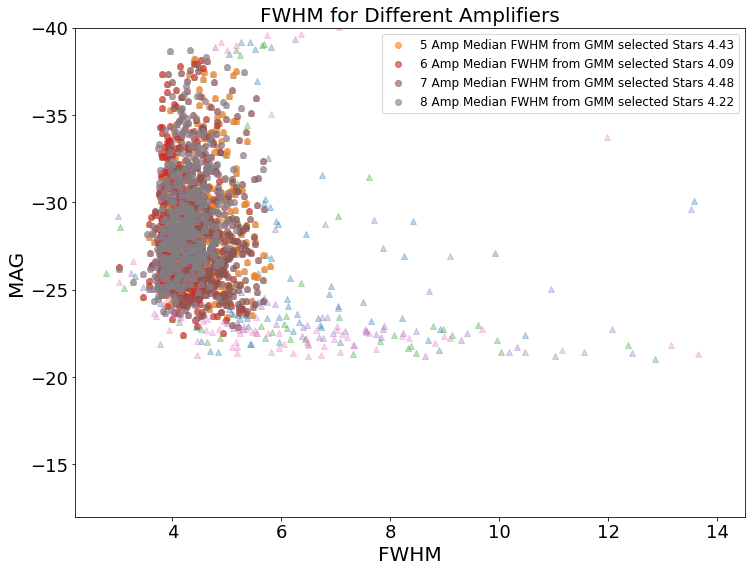

In [115]:
fig, ax = plt.subplots(figsize=(12, 9)) 
plt.rc('axes', titlesize=20)      # Title font size
plt.rc('axes', labelsize=20)      # X/Y label font size
plt.rc('xtick', labelsize=18)     # X tick label font size
plt.rc('ytick', labelsize=18)     # Y tick label font size
plt.rc('legend', fontsize=12)     # Legend font size
plt.rc('figure', titlesize=22)    # Figure title font size
plt.rc('font', size=15)  
for ii in range(4,8):
    X= amp_cut(ii,all_objects)
    cuta = all_objects[cutt][labelst == 0]['subset_id']==ii
    plt.scatter(X[:,0],X[:,2],marker='^',alpha = 0.3)
    plt.scatter(all_objects[cutt][labelst == 0]['FWHM'][cuta],-2.5*np.log(all_objects[cutt][labelst == 0]['flux'][cuta]),marker = 'o',label = str(ii+1)+' Amp Median FWHM from GMM selected Stars '+str(np.round(median_fwhm[ii],2)),alpha=0.6)
#c=labels, cmap='coolwarm'
plt.xlabel("FWHM")
plt.ylabel("MAG")
plt.ylim(-12.,-40)
plt.title("FWHM for Different Amplifiers")
plt.legend()
plt.show()